In [9]:


import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn import metrics

from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score

In [10]:
import pandas as pd

data = pd.read_csv("Training.csv")
data.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis,Unnamed: 133
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN


In [11]:

print('We have {} rows.'.format(data.shape[0]))
print('We have {} columns.'.format(data.shape[1]))

We have 4920 rows.
We have 134 columns.


In [12]:


print(np.sum(pd.isnull(data)))

itching                    0
skin_rash                  0
nodal_skin_eruptions       0
continuous_sneezing        0
shivering                  0
                        ... 
blister                    0
red_sore_around_nose       0
yellow_crust_ooze          0
prognosis                  0
Unnamed: 133            4920
Length: 134, dtype: int64


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [13]:


print(data['prognosis'].unique())

['Fungal infection' 'Allergy' 'GERD' 'Chronic cholestasis' 'Drug Reaction'
 'Peptic ulcer diseae' 'AIDS' 'Diabetes ' 'Gastroenteritis'
 'Bronchial Asthma' 'Hypertension ' 'Migraine' 'Cervical spondylosis'
 'Paralysis (brain hemorrhage)' 'Jaundice' 'Malaria' 'Chicken pox'
 'Dengue' 'Typhoid' 'hepatitis A' 'Hepatitis B' 'Hepatitis C'
 'Hepatitis D' 'Hepatitis E' 'Alcoholic hepatitis' 'Tuberculosis'
 'Common Cold' 'Pneumonia' 'Dimorphic hemmorhoids(piles)' 'Heart attack'
 'Varicose veins' 'Hypothyroidism' 'Hyperthyroidism' 'Hypoglycemia'
 'Osteoarthristis' 'Arthritis' '(vertigo) Paroymsal  Positional Vertigo'
 'Acne' 'Urinary tract infection' 'Psoriasis' 'Impetigo']


In [14]:


for col in data.columns[:-1]:
    if data[col].dtype != 'object':
        data[col] = data[col].astype(np.int64)

print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Columns: 134 entries, itching to Unnamed: 133
dtypes: float64(1), int64(132), object(1)
memory usage: 5.0+ MB
None


In [27]:


data.drop('Unnamed: 133', axis=1, inplace=True)

data.head()

KeyError: "['Unnamed: 133'] not found in axis"

In [28]:


print(data.dtypes)

itching                  int64
skin_rash                int64
nodal_skin_eruptions     int64
continuous_sneezing      int64
shivering                int64
                         ...  
inflammatory_nails       int64
blister                  int64
red_sore_around_nose     int64
yellow_crust_ooze        int64
prognosis               object
Length: 133, dtype: object


In [29]:


x = data.iloc[:, 0:-1]
print(x.shape)

y = data.iloc[:, -1]
print(y.shape)

(4920, 132)
(4920,)


In [30]:


cat_columns = x.select_dtypes(['object']).columns

x[cat_columns] = x[cat_columns].apply(lambda x: pd.factorize(x)[0])

print(x.head())

   itching  skin_rash  nodal_skin_eruptions  continuous_sneezing  shivering  \
0        1          1                     1                    0          0   
1        0          1                     1                    0          0   
2        1          0                     1                    0          0   
3        1          1                     0                    0          0   
4        1          1                     1                    0          0   

   chills  joint_pain  stomach_pain  acidity  ulcers_on_tongue  ...  \
0       0           0             0        0                 0  ...   
1       0           0             0        0                 0  ...   
2       0           0             0        0                 0  ...   
3       0           0             0        0                 0  ...   
4       0           0             0        0                 0  ...   

   pus_filled_pimples  blackheads  scurring  skin_peeling  \
0                   0           0    

In [31]:

x = data.iloc[:, 0:-1]
print(x.shape)

y = data.iloc[:, -1]
print(y.shape)

(4920, 132)
(4920,)


In [20]:


cat_columns = x.select_dtypes(['object']).columns

x[cat_columns] = x[cat_columns].apply(lambda x: pd.factorize(x)[0])

if y.dtype == 'object':
    y = pd.factorize(y)[0]

In [32]:


X_train, X_test, Y_train, Y_test = train_test_split(
    x,
    y,
    test_size=.3,
    shuffle=False
)

In [33]:

RF = RandomForestClassifier()

RF.fit(X_train, Y_train)

Y_pred = RF.predict(X_test)

In [34]:


accuracy = accuracy_score(Y_test, Y_pred)
print('Accuracy: %f' % accuracy)

precision = metrics.precision_score(
    Y_test,
    Y_pred,
    average='weighted',
    labels=np.unique(Y_pred)
)

print('Precision: %f' % precision)

recall = metrics.recall_score(
    Y_test,
    Y_pred,
    average='weighted',
    labels=np.unique(Y_pred)
)

print('Recall: %f' % recall)

f1 = metrics.f1_score(
    Y_test,
    Y_pred,
    average='weighted',
    labels=np.unique(Y_pred)
)

print('F1 score: %f' % f1)

Accuracy: 1.000000
Precision: 1.000000
Recall: 1.000000
F1 score: 1.000000


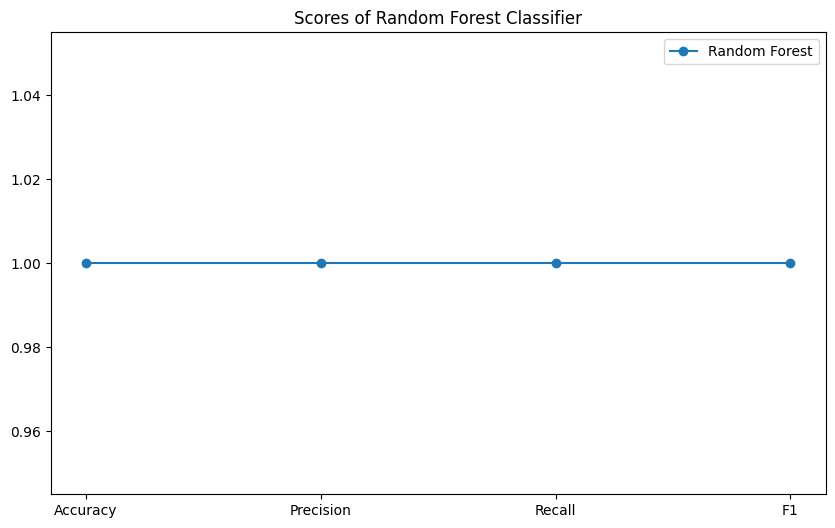

In [24]:


plt.figure(figsize=(10,6))

x1 = np.array(['Accuracy', 'Precision', 'Recall', 'F1'])

y1 = np.array([accuracy, precision, recall, f1])

plt.plot(x1, y1, marker='o', label='Random Forest')

plt.title("Scores of Random Forest Classifier")

plt.legend()

plt.show()

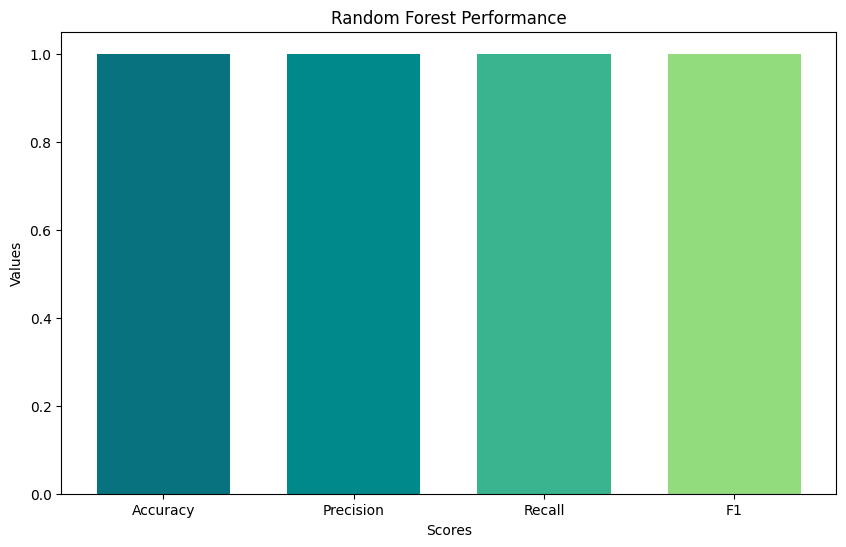

In [25]:


left = [1, 2, 3, 4]

plt.figure(figsize=(10,6))

height = [accuracy, precision, recall, f1]

tick_label = ['Accuracy', 'Precision', 'Recall', 'F1']

plt.bar(
    left,
    height,
    tick_label=tick_label,
    width=0.7,
    color=['#08737f', '#00898a', '#39b48e', '#92dc7e']
)

plt.xlabel('Scores')

plt.ylabel('Values')

plt.title('Random Forest Performance')

plt.show()